In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('17-cardekho.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.drop(columns = 'Unnamed: 0' , inplace = True , axis = 1)
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


In [6]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [7]:
object_columns = ['car_name' , 'brand' , 'model' , 'seller_type' , 'fuel_type' , 'transmission_type']
for col in object_columns : 
    print(df[col].value_counts()) 

car_name
Hyundai i20              906
Maruti Swift Dzire       890
Maruti Swift             781
Maruti Alto              778
Honda City               757
                        ... 
Mercedes-AMG C             1
Rolls-Royce Ghost          1
Maserati Quattroporte      1
Isuzu MUX                  1
Force Gurkha               1
Name: count, Length: 121, dtype: int64
brand
Maruti           4992
Hyundai          2982
Honda            1485
Mahindra         1011
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
Audi              192
Datsun            170
Jaguar             59
Land Rover         51
Jeep               41
Kia                32
Porsche            21
Volvo              20
MG                 19
Mini               17
Nissan             11
Lexus              10
Isuzu               8
Bentley             3
Maserati            2
ISUZU               2
Ferrari    

In [8]:
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
197,Honda City,Honda,City,8,70000,Individual,Petrol,Manual,16.80,1497,116.30,5,545000
360,Maruti Baleno,Maruti,Baleno,2,5000,Individual,Petrol,Automatic,21.40,1197,83.10,5,686000
1353,Maruti Swift Dzire,Maruti,Swift Dzire,4,50000,Individual,Diesel,Manual,28.40,1248,74.02,5,680000
1429,Maruti Wagon R,Maruti,Wagon R,13,100000,Individual,Petrol,Manual,18.90,1061,67.00,5,150000
1485,Hyundai i20,Hyundai,i20,3,50000,Individual,Petrol,Manual,18.60,1197,81.83,5,625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15229,Maruti Swift,Maruti,Swift,8,80000,Individual,Diesel,Manual,22.90,1248,74.00,5,350000
15324,Maruti Wagon R,Maruti,Wagon R,6,50000,Individual,CNG,Manual,26.60,998,58.16,5,450000
15367,Tata Tiago,Tata,Tiago,4,30000,Individual,Petrol,Manual,23.84,1199,84.00,5,350000
15378,Hyundai Grand,Hyundai,Grand,6,30000,Individual,Petrol,Manual,18.90,1197,82.00,5,450000


In [9]:
df.drop_duplicates(keep = 'first' , ignore_index = True , inplace = True)
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [10]:
df[df['seats'] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3207,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12504,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [11]:
df['seats'] = df['seats'].replace(0 , 5)
df[df['seats'] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [12]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.000000,1.524400e+04,15244.000000,15244.000000,15244.000000,15244.000000,1.524400e+04
mean,6.041131,5.563958e+04,19.697333,1486.171543,100.607652,5.326817,7.747014e+05
std,3.016228,5.176630e+04,4.169307,520.419390,42.915687,0.806464,8.946761e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,2.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.590000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [13]:
pd.set_option('display.float_format' ,'{:.3f}'.format)

In [14]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.000,15244.000,15244.000,15244.000,15244.000,15244.000,15244.000
mean,6.041,55639.582,19.697,1486.172,100.608,5.327,774701.448
std,3.016,51766.299,4.169,520.419,42.916,0.806,894676.082
min,0.000,100.000,4.000,793.000,38.400,2.000,40000.000
25%,4.000,30000.000,17.000,1197.000,74.000,5.000,385000.000
50%,6.000,50000.000,19.670,1248.000,88.500,5.000,559000.000
75%,8.000,70000.000,22.700,1582.000,117.300,5.000,825000.000
max,29.000,3800000.000,33.540,6592.000,626.000,9.000,39500000.000


In [15]:
# EDA
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.700,796,46.300,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.900,1197,82.000,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.000,1197,80.000,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.920,998,67.100,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.770,1498,98.590,5,570000


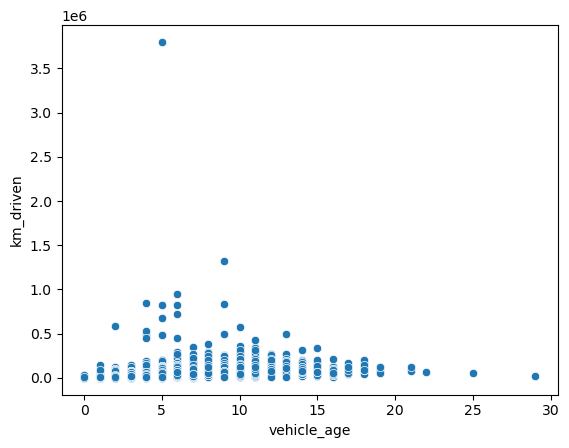

In [16]:
sns.scatterplot(data = df , x = 'vehicle_age' , y = 'km_driven')
plt.show()

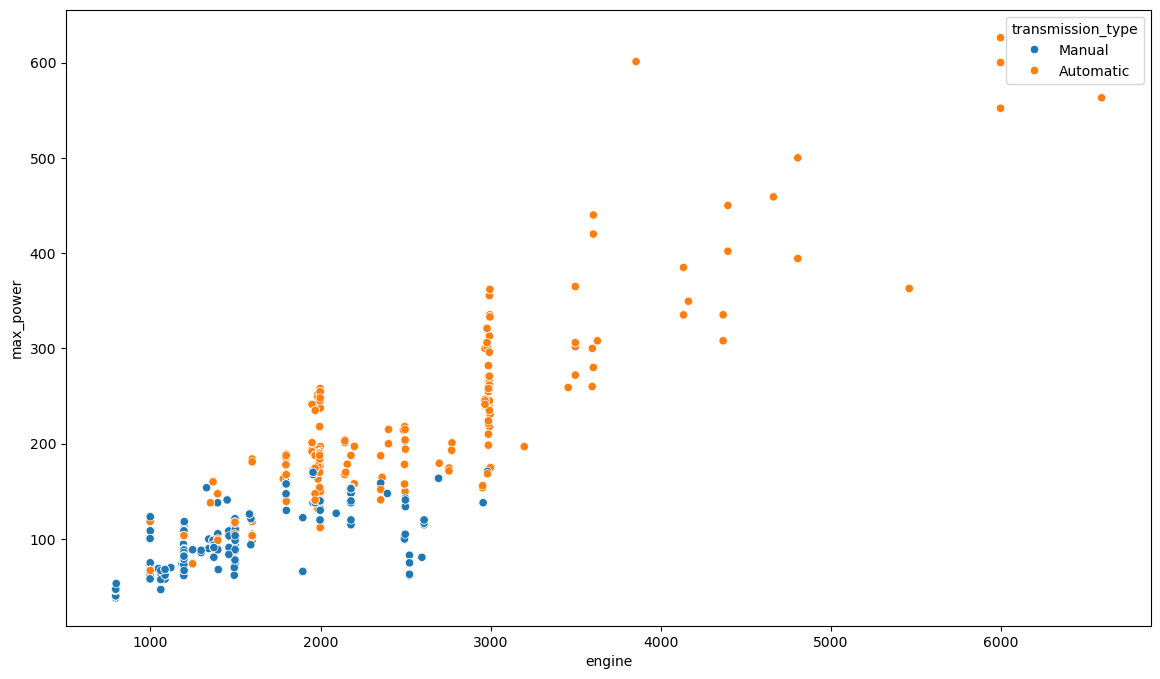

In [17]:
plt.figure(figsize = (14 , 8))
sns.scatterplot(data = df , x = 'engine' , y = 'max_power' , hue = 'transmission_type')
plt.show()

In [18]:
df = df[(df['max_power'] < 500)]
df = df[(df['km_driven'] < 1200000)]


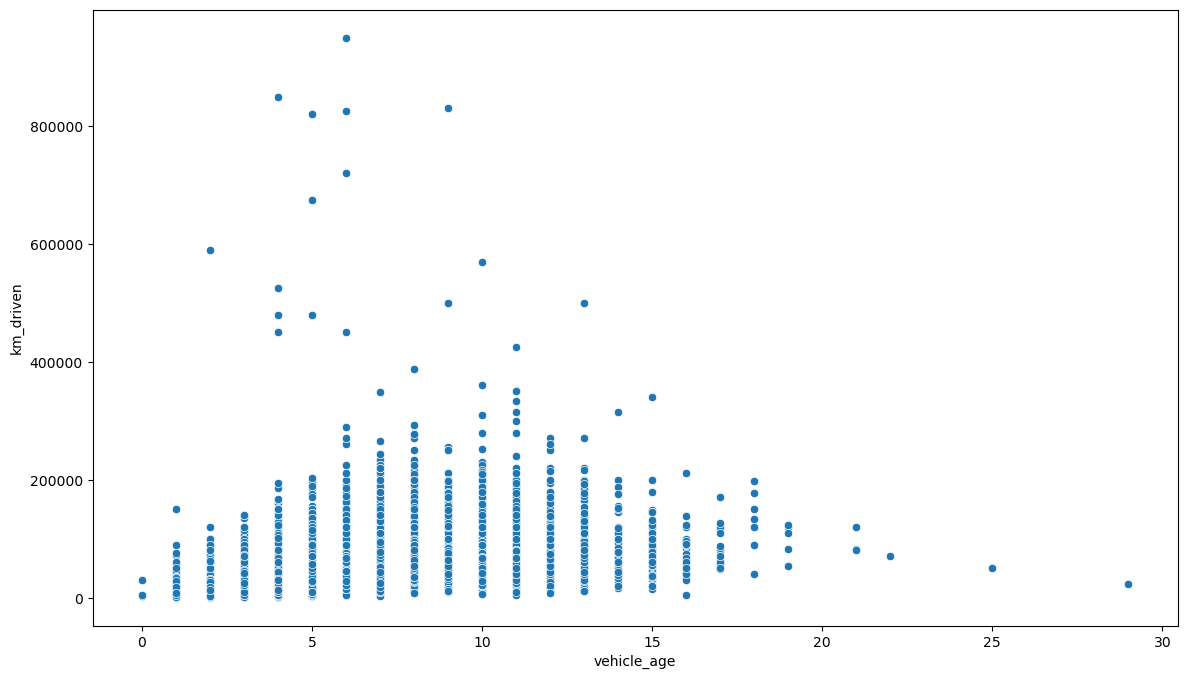

In [19]:
plt.figure(figsize = (14 , 8))
sns.scatterplot(data = df , x = 'vehicle_age' , y = 'km_driven')
plt.show()

<Axes: xlabel='vehicle_age', ylabel='selling_price'>

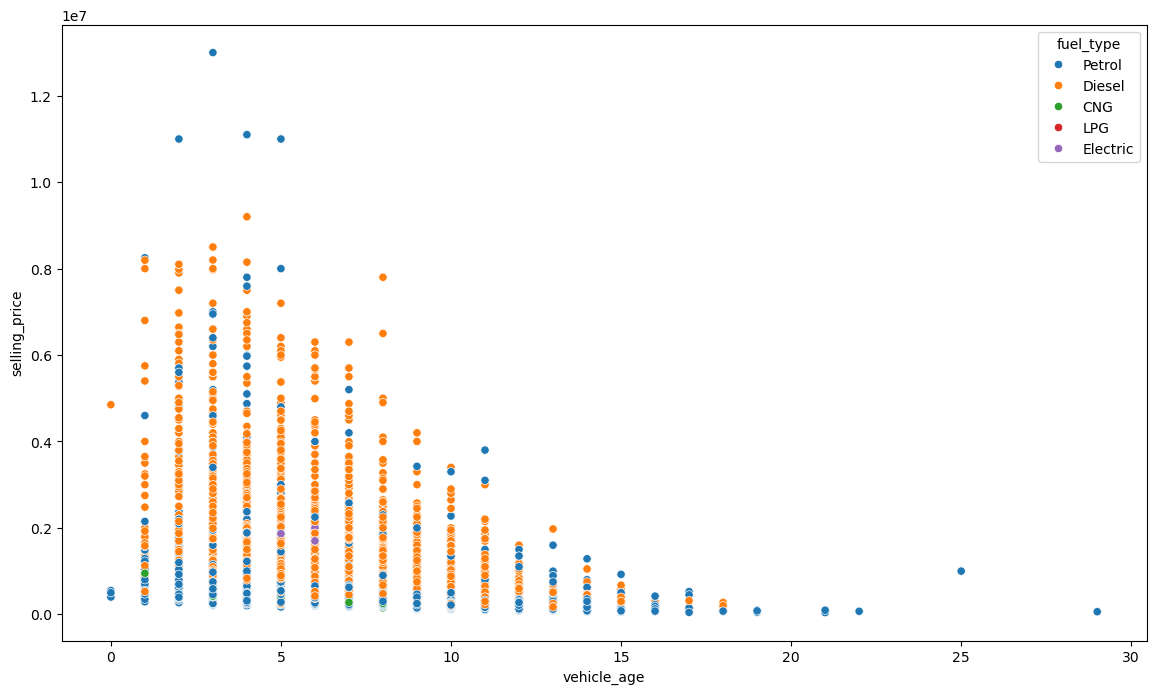

In [20]:
plt.figure(figsize = (14 , 8))
sns.scatterplot(data = df , y = 'selling_price' , x = 'vehicle_age' , hue = 'fuel_type')

In [21]:
# Encode 

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.700,796,46.300,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.900,1197,82.000,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.000,1197,80.000,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.920,998,67.100,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.770,1498,98.590,5,570000


In [24]:
X = df.drop(columns = 'selling_price' , axis = 1)
y = df['selling_price']

from sklearn.model_selection import train_test_split

X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 15)

X_train.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
8994,Mahindra Scorpio,Mahindra,Scorpio,8,56000,Dealer,Diesel,Manual,12.050,2179,120.000,8
7706,Maruti Eeco,Maruti,Eeco,5,40000,Individual,Petrol,Manual,15.370,1196,73.000,5
5332,Mahindra XUV500,Mahindra,XUV500,4,58500,Dealer,Diesel,Manual,16.000,2179,140.000,7
2936,Hyundai i10,Hyundai,i10,9,40000,Dealer,Petrol,Automatic,16.950,1197,78.900,5
6419,Maruti Baleno,Maruti,Baleno,4,32000,Dealer,Petrol,Manual,21.010,1197,81.800,5


In [25]:
 X_train['car_name'].value_counts() / len(X_train)

car_name
Hyundai i20             0.060
Maruti Swift Dzire      0.057
Maruti Alto             0.051
Maruti Swift            0.051
Honda City              0.051
                         ... 
Maserati Quattroporte   0.000
Maruti Dzire LXI        0.000
Tata Altroz             0.000
Isuzu MUX               0.000
Maserati Ghibli         0.000
Name: count, Length: 116, dtype: float64

In [26]:
freq_columns = ['car_name' , 'brand' , 'model']
for col in freq_columns : 
    freq = X_train[col].value_counts() / len(X_train)
    X_train[col + '_freq'] = X_train[col].map(freq)
    X_test[col + '_freq'] = X_test[col].map(freq)

    mean_freq = freq.mean()
    X_test[col + '_freq'] = X_test[col + '_freq'].fillna(mean_freq)

In [27]:
X_train.drop(columns = freq_columns , axis = 1 , inplace = True)

In [28]:
X_test.drop(columns = freq_columns , axis = 1 , inplace = True)
X_test.head()

,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_freq,brand_freq,model_freq
13653,5,47935,Dealer,Petrol,Automatic,14.700,1496,120.690,5,0.024,0.050,0.024
14789,3,28061,Dealer,Petrol,Automatic,15.000,1396,100.000,5,0.060,0.195,0.060
8504,11,97780,Dealer,Diesel,Manual,25.200,1493,98.630,5,0.060,0.195,0.060
9545,2,35000,Individual,Petrol,Manual,19.500,1199,88.760,5,0.024,0.099,0.024
1968,7,29000,Dealer,Petrol,Manual,15.000,1598,105.000,5,0.012,0.021,0.012


In [29]:
one_hot_column = ['seller_type' , 'fuel_type' , 'transmission_type']

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer(transformers = [
    ('onehot' , OneHotEncoder(dtype = int , handle_unknown = 'ignore' , drop = 'first') , one_hot_column)
] , remainder = 'passthrough')

In [30]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [31]:
column_name = transformer.get_feature_names_out()

In [32]:
X_train = pd.DataFrame(data = X_train , columns = column_name)
X_test = pd.DataFrame(data = X_test , columns = column_name)
X_test.head()

,onehot__seller_type_Individual,onehot__seller_type_Trustmark Dealer,onehot__fuel_type_Diesel,onehot__fuel_type_Electric,onehot__fuel_type_LPG,onehot__fuel_type_Petrol,onehot__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_freq,remainder__brand_freq,remainder__model_freq
0,0.000,0.000,0.000,0.000,0.000,1.000,0.000,5.000,47935.000,14.700,1496.000,120.690,5.000,0.024,0.050,0.024
1,0.000,0.000,0.000,0.000,0.000,1.000,0.000,3.000,28061.000,15.000,1396.000,100.000,5.000,0.060,0.195,0.060
2,0.000,0.000,1.000,0.000,0.000,0.000,1.000,11.000,97780.000,25.200,1493.000,98.630,5.000,0.060,0.195,0.060
3,1.000,0.000,0.000,0.000,0.000,1.000,1.000,2.000,35000.000,19.500,1199.000,88.760,5.000,0.024,0.099,0.024
4,0.000,0.000,0.000,0.000,0.000,1.000,1.000,7.000,29000.000,15.000,1598.000,105.000,5.000,0.012,0.021,0.012


In [33]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor 

ada = AdaBoostRegressor()

ada.fit(X_train , y_train)

AdaBoostRegressor()

In [34]:
y_pred = ada.predict(X_test)
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error 

print('R2 : ' , r2_score(y_test , y_pred))

R2 :  0.6931816349443518


In [35]:
# Hyperparamether Tuning

from sklearn.model_selection import RandomizedSearchCV

params = {
    'estimator__max_depth' : [3 , 4 , 5 , 7 ,10 , None],
    'learning_rate' : [0.01 , 0.1 , 1 , 1.5 , 2.0],
    'n_estimators' : [50 , 100 , 200 ],
    'loss' : ['linear' , 'square' , 'exponential']
}
grid = RandomizedSearchCV(estimator = AdaBoostRegressor(estimator = DecisionTreeRegressor()) , param_distributions = params , scoring = 'r2' , n_jobs = -1 , cv = 5 )
grid.fit(X_train , y_train)
y_pred = grid.predict(X_test)
print('R2 : ' , r2_score(y_test , y_pred))

R2 :  0.9331197324504755
